# RMSNorm Kernel Benchmark — RTX 5080, sm_120

Comparing all three CUDA kernel versions against PyTorch (eager + compiled) and Triton.

| Kernel | Strategy | HBM passes |
|--------|----------|------------|
| V1 | One thread per row — serial, non-coalesced | 2R + 1W |
| V2 | One block per row — 256 threads, warp+block reduction | 2R + 1W |
| V3 | One block per row — 128 threads, warp+block reduction | 2R + 1W |

**Data collection:**
```bash
# 1. Python baselines — outputs CSV: size,pytorch_us,compiled_us,triton_us
python benchmark/sweep_rmsnorm.py

# 2. CUDA timings — read 'Median Time (ms)' × 1000 → µs for each kernel
# (uncomment V1/V2 in main() to bench all three at once)
./build/bin/RMSNorm_sm120  512 1024
./build/bin/RMSNorm_sm120 1024 1024
./build/bin/RMSNorm_sm120 2048 1024
./build/bin/RMSNorm_sm120 4096 1024
./build/bin/RMSNorm_sm120 8192 1024
./build/bin/RMSNorm_sm120 8192 2048
./build/bin/RMSNorm_sm120 8192 4096
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data (µs) ─────────────────────────────────────────────────────────────────
# Python baselines — from: python benchmark/sweep_rmsnorm.py
#   outputs CSV: size,pytorch_us,compiled_us,triton_us
#
# CUDA timings — from: ./build/bin/RMSNorm_sm120 N C  →  Median Time (ms) * 1000
#   order in output: V1, V2, V3

sizes = [
    '512×1024', '1024×1024', '2048×1024', '4096×1024',
    '8192×1024', '8192×2048', '8192×4096'
]

v1       = [329.7, 327.7, 325.3, 329.4,  368.6,  626.7, 1261.6]
v2       = [ 12.3,  14.3,  22.5,  45.1,   85.7,  170.0,  335.9]
v3       = [ 10.2,  18.4,  24.6,  38.9,   79.9,  170.0,  380.9]
pytorch  = [  7.9,  12.3,  24.3,  45.1,   87.6,  167.9,  358.1]
compiled = [  6.1,   9.9,  20.2,  43.0,   84.0,  165.9,  327.7]
triton   = [  7.8,  11.9,  22.2,  42.7,   84.0,  165.5,  327.3]

# ── Dark theme ────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
GRID_C = '#ffffff'
TEXT   = '#e6edf3'
BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'
PURPLE = '#bc8cff'
YELLOW = '#e3b341'
PINK   = '#ff7b72'
TEAL   = '#39d353'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         GRID_C,
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

x = np.arange(len(sizes))
print('Data loaded.')

Data loaded.


## 1 — All kernels: latency across sizes

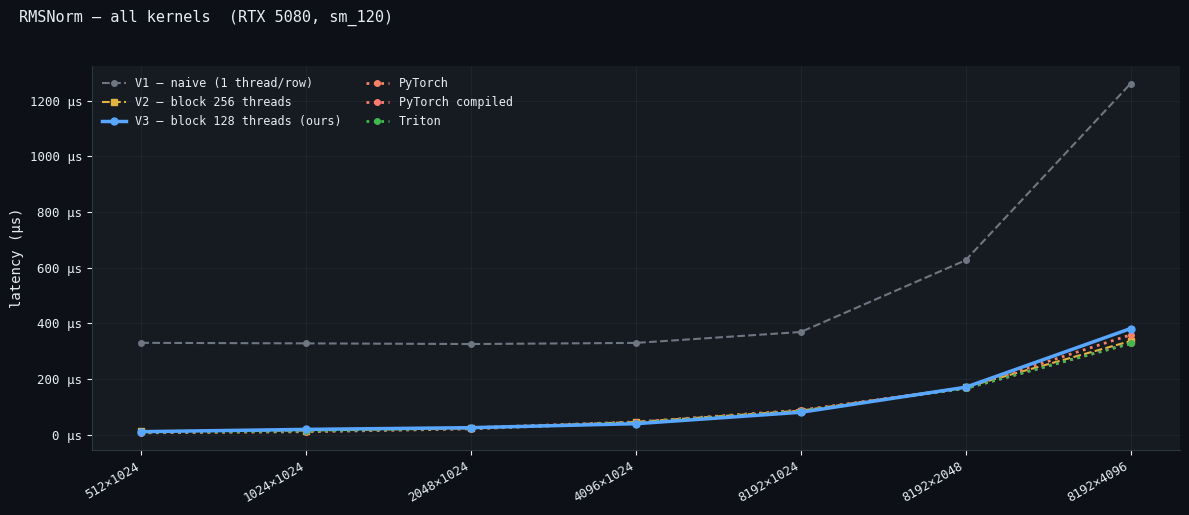

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# CUDA kernels
ax.plot(x, v1,       color='#6e7681', linewidth=1.5, marker='o', markersize=4,
        linestyle='--', label='V1 — naive (1 thread/row)', zorder=2)
ax.plot(x, v2,       color=YELLOW,    linewidth=1.5, marker='s', markersize=4,
        linestyle='--', label='V2 — block 256 threads', zorder=2)
ax.plot(x, v3,       color=BLUE,      linewidth=2.5, marker='o', markersize=5,
        label='V3 — block 128 threads (ours)', zorder=4)
# Baselines
ax.plot(x, pytorch,  color=ORANGE,    linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch', zorder=3)
ax.plot(x, compiled, color=PINK,      linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,     linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, loc='upper left', labelcolor=TEXT, ncol=2)
ax.tick_params(labelsize=9)

fig.suptitle('RMSNorm — all kernels  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rmsnorm_all.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 2 — V3 vs best baselines: latency across sizes

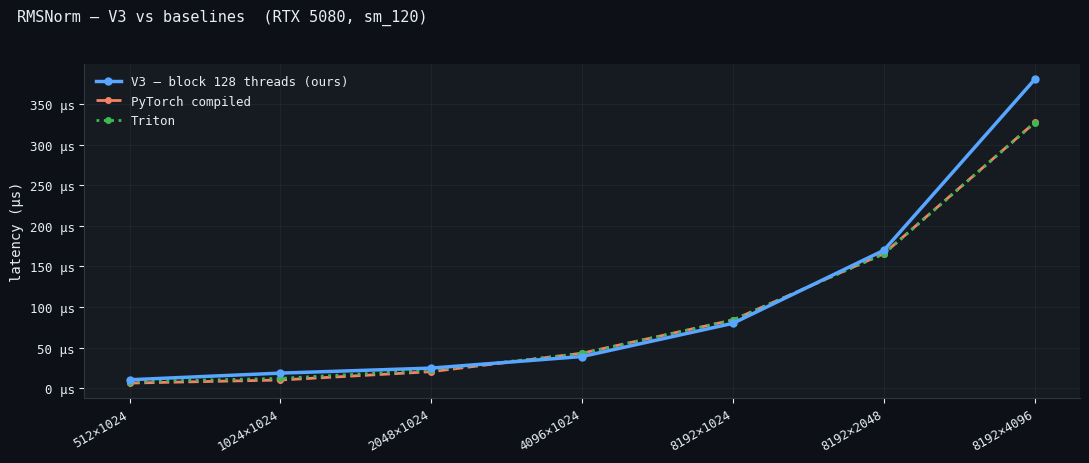

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(x, v3,       color=BLUE,   linewidth=2.5, marker='o', markersize=5,
        label='V3 — block 128 threads (ours)', zorder=4)
ax.plot(x, compiled, color=ORANGE, linewidth=2,   marker='o', markersize=4,
        linestyle='--', label='PyTorch compiled', zorder=3)
ax.plot(x, triton,   color=GREEN,  linewidth=2,   marker='o', markersize=4,
        linestyle=':', label='Triton', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, loc='upper left', labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('RMSNorm — V3 vs baselines  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rmsnorm_v3_vs_baselines.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 3 — Sizes where V3 beats both PyTorch compiled and Triton

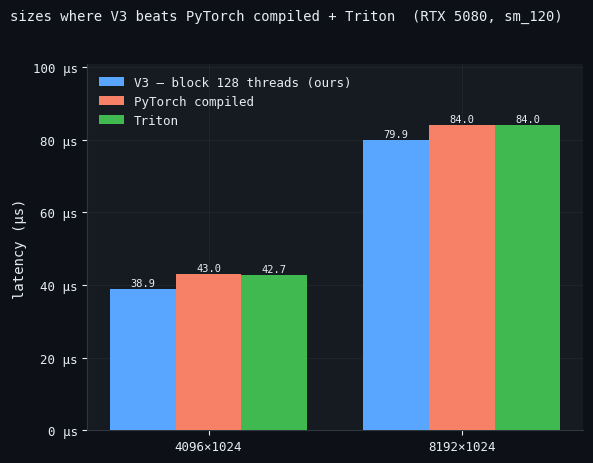

V3 wins at 2/7 sizes tested.


In [5]:
win_idx   = [i for i in range(len(sizes)) if v3[i] < compiled[i] and v3[i] < triton[i]]
win_sizes = [sizes[i]    for i in win_idx]
v3_vals   = [v3[i]       for i in win_idx]
cmp_vals  = [compiled[i] for i in win_idx]
tri_vals  = [triton[i]   for i in win_idx]

n     = len(win_sizes)
xw    = np.arange(n)
width = 0.26

fig, ax = plt.subplots(figsize=(max(6, n * 2.2), 4.5))

b1 = ax.bar(xw - width, v3_vals,  width, label='V3 — block 128 threads (ours)', color=BLUE,   zorder=3)
b2 = ax.bar(xw,         cmp_vals, width, label='PyTorch compiled',               color=ORANGE, zorder=3)
b3 = ax.bar(xw + width, tri_vals, width, label='Triton',                         color=GREEN,  zorder=3)

for bars in (b1, b2, b3):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7.5, color=TEXT
        )

ax.set_xticks(xw)
ax.set_xticklabels(win_sizes, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)
if v3_vals:
    ax.set_ylim(0, max(cmp_vals + tri_vals) * 1.2)

fig.suptitle('sizes where V3 beats PyTorch compiled + Triton  (RTX 5080, sm_120)',
             fontsize=10, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rmsnorm_wins.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'V3 wins at {len(win_idx)}/{len(sizes)} sizes tested.')

## 4 — Kernel progression at 8192×1024

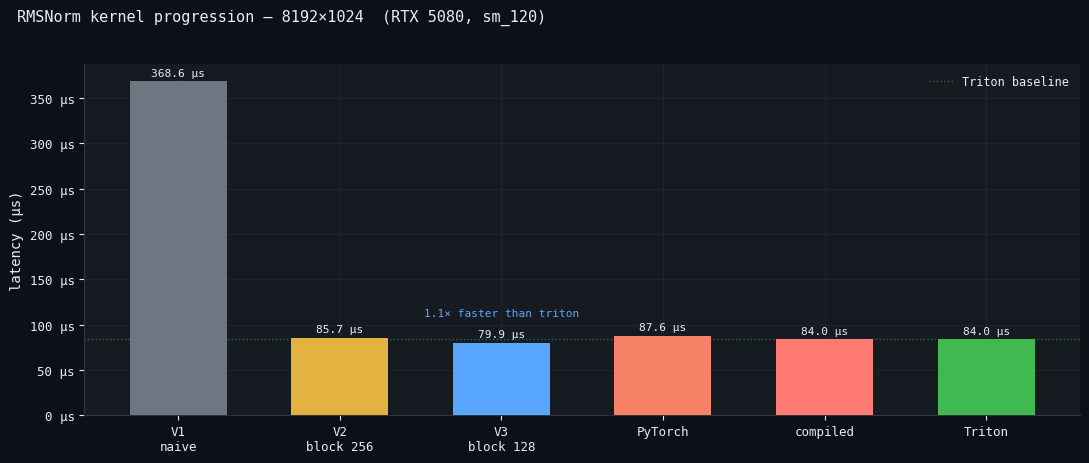

In [6]:
IDX = 4  # 8192×1024

kern_names  = ['V1\nnaive', 'V2\nblock 256', 'V3\nblock 128',
               'PyTorch', 'compiled', 'Triton']
kern_vals   = [v1[IDX], v2[IDX], v3[IDX],
               pytorch[IDX], compiled[IDX], triton[IDX]]
kern_colors = ['#6e7681', YELLOW, BLUE, ORANGE, PINK, GREEN]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(range(len(kern_names)), kern_vals, color=kern_colors, zorder=3, width=0.6)

for bar, val in zip(bars, kern_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(kern_vals) * 0.01,
        f'{val:.1f} µs',
        ha='center', va='bottom', fontsize=8, color=TEXT
    )

ax.axhline(triton[IDX], color=GREEN, linewidth=1, linestyle=':', alpha=0.5, label='Triton baseline')

ax.set_xticks(range(len(kern_names)))
ax.set_xticklabels(kern_names, fontsize=9)
ax.set_ylabel('latency (µs)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)} µs'))
ax.legend(fontsize=8.5, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

# Annotate speedup of V3 over V1
if triton[IDX] > 0 and v3[IDX] > 0:
    speedup = triton[IDX] / v3[IDX]
    ax.annotate(
        f'{speedup:.1f}× faster than triton',
        xy=(2, v3[IDX]), xytext=(2, v3[IDX] + triton[IDX] * 0.35),
        fontsize=8, color=BLUE, ha='center'
    )

fig.suptitle(f'RMSNorm kernel progression — {sizes[IDX]}  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rmsnorm_progression.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()

## 5 — Speedup of V3 over PyTorch compiled and Triton, across sizes

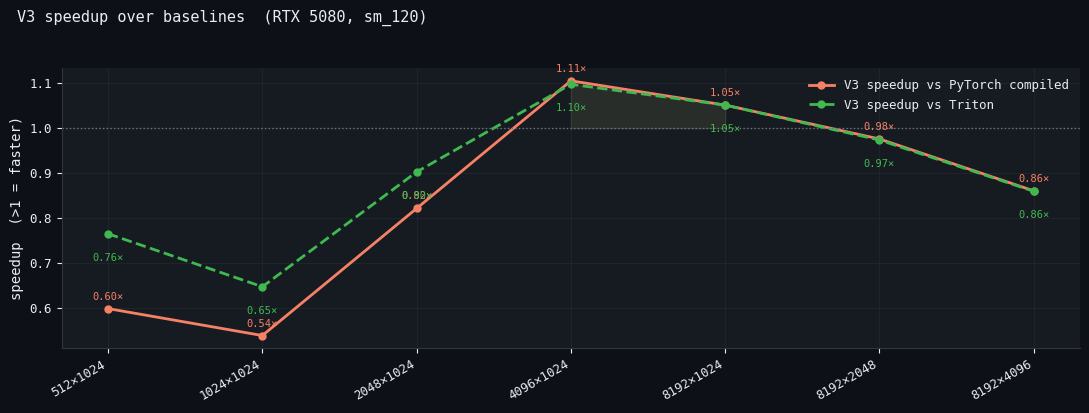

In [7]:
eps = 1e-9  # avoid div-by-zero while data is zeros
speedups_compiled = [c / (b + eps) for c, b in zip(compiled, v3)]
speedups_triton   = [t / (b + eps) for t, b in zip(triton,   v3)]

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, speedups_compiled, color=ORANGE, linewidth=2, marker='o', markersize=5,
        label='V3 speedup vs PyTorch compiled')
ax.plot(x, speedups_triton,   color=GREEN,  linewidth=2, marker='o', markersize=5,
        linestyle='--', label='V3 speedup vs Triton')
ax.axhline(1.0, color='#6e7681', linewidth=1, linestyle=':')
ax.fill_between(x, 1.0, speedups_compiled,
                where=[s > 1 for s in speedups_compiled],
                color=ORANGE, alpha=0.08)
ax.fill_between(x, 1.0, speedups_triton,
                where=[s > 1 for s in speedups_triton],
                color=GREEN, alpha=0.08)

for i, (sc, st) in enumerate(zip(speedups_compiled, speedups_triton)):
    ax.text(i, sc + 0.02, f'{sc:.2f}×', ha='center', fontsize=7.5, color=ORANGE)
    ax.text(i, st - 0.06, f'{st:.2f}×', ha='center', fontsize=7.5, color=GREEN)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('speedup  (>1 = faster)', fontsize=10)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('V3 speedup over baselines  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)
plt.tight_layout()
plt.savefig('rmsnorm_speedup.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()